# pyGAGE + Pathview-Plus Research Notebook

**Focus:** pathway-level interpretation, usability, and reproducibility  
**Perspective:** Computer Science + Biology student interested in bioinformatics and computational biology

## why approach this way?

I wanted to approach pyGAGE in the way I naturally think about bioinformatics: not just as code that produces an output table, but as a workflow that has to connect computation back to biological meaning.

One thing I keep running into as someone between Computer Science and Biology is that both sides can get lost for different reasons. A CS student may understand the data structures and functions but miss the biological interpretation. A biology student may understand the biological question but get blocked by setup, file formats, gene identifiers, or function arguments.

So I am using this notebook to ask a few practical questions:

1. Can a new user get pyGAGE running in a clean Colab environment?
2. What does the package structure look like from a first-time user perspective?
3. What input format does the workflow expect?
4. Where could gene identifiers, sample grouping, or indexing cause confusion?
5. Can I connect the output back to real biological reasoning instead of stopping at a table?
6. What small changes would make this easier for students, biologists, and computational users?

My goal is to make this useful as both an analysis draft and a set of notes on how the workflow feels from the user side.


In [1]:
!pip install -q pygage polars numpy scipy matplotlib seaborn requests pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.1 MB/s eta 0:00:00


## Setup note

The package installed successfully in a fresh Colab runtime, which is a good first sign for accessibility!!!! I wanted to test this first because a lot of bioinformatics workflows become intimidating before the analysis even starts (I had this happen with biopython when I was a freshman) just because setup is unclear or dependenc heavy (In this case it was not!).

Starting with a clean install also helps separate setup problems from actual analysis problems. If something breaks later, I can be more confident that the issue is probably related to input format, sample grouping, gene identifiers, or how I am calling the workflow rather than the basic environment.

In [2]:
import sys
import importlib

print("Python version:")
print(sys.version)

print("\nChecking that the main packages imported correctly:\n")

for package in ["pygage", "polars", "numpy", "scipy", "matplotlib", "seaborn", "requests", "pandas"]:
    try:
        imported_package = importlib.import_module(package)
        print(package, "worked")
    except Exception as error:
        print(package, "did not work:", error)

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Checking that the main packages imported correctly:

pygage worked
polars worked
numpy worked
scipy worked
matplotlib worked
seaborn worked
requests worked
pandas worked


In [3]:
#Just a quick confirmation

In [4]:
import pygage

print("What is available directly inside pygage?\n")

for item in dir(pygage):
    if not item.startswith("_"):
        print(item)

What is available directly inside pygage?



## First package observation

`pygage` imports successfully, so the package is available in the Colab environment.

The main workflow appears to live inside the package’s submodules rather than directly at the top level `import pygage`. That makes sense for a package with multiple pieces, especially because pyGAGE includes separate tools for gene ID handling, pathway databases, data processing, core GAGE analysis, results, and visualization.

My next step is to look through those modules directly so I can understand the workflow more clearly and make sure I am using the package the way it is intended.

In [5]:
import importlib

modules = [
    "pygage.gene_id_utils",
    "pygage.pathway_database_utils",
    "pygage.data_processing_utils",
    "pygage.gage_core",
    "pygage.results_analysis",
    "pygage.visualization_utils"
]

for module_name in modules:
    try:
        module = importlib.import_module(module_name)
        print(module_name, "worked")
    except Exception as error:
        print(module_name, "did not work:", error)

pygage.gene_id_utils worked
pygage.pathway_database_utils worked
pygage.data_processing_utils worked
pygage.gage_core did not work: No module named 'pygage.gage_core'
pygage.results_analysis worked
pygage.visualization_utils worked


## Module check

Most of the pyGAGE modules imported successfully, including the parts for gene ID handling, pathway database tools, data processing, results, and visualization.

I also tried the core analysis import shown on the package page:

```python
from pygage.gage_core import GAGEPreparation, GAGEAnalysis
```

In this Colab setup, that specific import did not load directly, so I am going to inspect the installed package structure next. I want to understand where the main analysis functions live in this environment before I keep going.

I think this is a helpful step because pyGAGE has several pieces, and checking the available modules first helps me understand the workflow more clearly before I start running the analysis.

In [6]:
import pkgutil
import pygage

print("Modules available inside the installed pyGAGE package:\n")

available_modules = []

for module in pkgutil.iter_modules(pygage.__path__):
    available_modules.append(module.name)
    print(module.name)

Modules available inside the installed pyGAGE package:

core
data_processing_utils
gene_id_utils
pathway_database_utils
results_analysis
tests
visualization_utils


## Installed package structure

After inspecting the installed package directly, I can see that this Colab version includes a module called `core`.

That is helpful because it gives me the next place to look for the main analysis functions. Instead of assuming the workflow, I am checking the installed package structure and following where the analysis code actually lives in this environment.

In [7]:
from pygage import core
import inspect

print("Functions and classes inside pygage.core:\n")

for item_name in dir(core):
    if not item_name.startswith("_"):
        item = getattr(core, item_name)

        if callable(item):
            try:
                print(item_name, inspect.signature(item))
            except:
                print(item_name)

Functions and classes inside pygage.core:

Dict (*args, **kwargs)
GAGEAnalysis ()
GAGEPreparation ()
List (*args, **kwargs)
Optional (*args, **kwds)
Tuple (*args, **kwargs)


## Core workflow location

The main GAGE workflow classes are available inside `pygage.core` in this Colab environment.

This gives me the import path I need for the analysis:

```python
from pygage.core import GAGEPreparation, GAGEAnalysis
```

I’m glad I checked the installed package directly because now I can keep going using the module structure that works in this runtime.

In [8]:
from pygage.core import GAGEPreparation, GAGEAnalysis
import inspect

print("Methods inside GAGEPreparation:\n")
prep = GAGEPreparation()

for name in dir(prep):
    if not name.startswith("_"):
        item = getattr(prep, name)
        if callable(item):
            try:
                print(name, inspect.signature(item))
            except:
                print(name)

print("\nMethods inside GAGEAnalysis:\n")
gage = GAGEAnalysis()

for name in dir(gage):
    if not name.startswith("_"):
        item = getattr(gage, name)
        if callable(item):
            try:
                print(name, inspect.signature(item))
            except:
                print(name)

Methods inside GAGEPreparation:

prepare_expression (data: polars.dataframe.frame.DataFrame, ref_indices: Optional[List[int]] = None, samp_indices: Optional[List[int]] = None, comparison: str = 'paired', same_dir: bool = True, use_fold: bool = True) -> polars.dataframe.frame.DataFrame

Methods inside GAGEAnalysis:

filter_significant (cutoff: float = 0.1, use_q: bool = True) -> Dict[str, polars.dataframe.frame.DataFrame]
run_gage (expression_data: polars.dataframe.frame.DataFrame, gene_sets: Dict[str, List[str]], gene_col: str = 'gene_id', set_size_range: Tuple[int, int] = (10, 500), same_dir: bool = True, test_method: str = 't-test', fdr_method: str = 'BH') -> Dict[str, polars.dataframe.frame.DataFrame]


## Method check

Now that I found the core workflow classes, I inspected the methods inside them instead of guessing the function names.

`GAGEPreparation` has:

```python
prepare_expression(...)
```

`GAGEAnalysis` has:

```python
run_gage(...)
filter_significant(...)
```

This is helpful because it gives the actual workflow:

1. prepare the expression matrix
2. run GAGE with gene sets
3. filter significant pathway results

I also noticed that `run_gage` expects a gene column called `gene_id` by default, which is useful to know before building the input table.

# Controlled biological test case

Before using a public dataset, I want to create a small controlled expression matrix where I already know the expected direction of the signal.

This helps me check whether the workflow makes sense before adding the messiness of real data.

The toy system below is cancer/signaling themed because it gives an intuitive biological pattern:

- growth and inflammatory signaling genes move upward
- tumor suppressor, DNA repair, and apoptosis associated genes move downward
- some pathways are intentionally mixed because real biology is rarely perfectly clean

This is not meant to be a discovery dataset. It is a controlled test case to make sure I understand the workflow.

In [9]:
## For this cell, I used ChatGPT as a coding helper to set up the simulated expression matrix, then I reviewed the gene groups as a controlled toy example rather than treating them like real experimental results.
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import json

np.random.seed(7)

genes = [
    "TP53", "EGFR", "MYC", "KRAS", "NRAS", "BRAF", "PIK3CA", "PTEN", "AKT1", "MTOR",
    "MAPK1", "MAPK3", "STAT3", "JAK2", "IL6", "TNF", "VEGFA", "HIF1A", "CDK1", "CDK2",
    "CCND1", "RB1", "BRCA1", "BRCA2", "RAD51", "CASP3", "BCL2", "BAX", "MKI67", "TGFB1",
    "SMAD2", "SMAD3", "SMAD4", "ERBB2", "ESR1", "FOXO3", "NFKB1", "RELA", "CXCL8", "MMP9",
    "CDH1", "VIM", "SNAI1", "TWIST1", "MMP2", "MMP14", "CCL2", "CXCL10", "IFNG", "IRF1"
]

control_1 = np.random.normal(8, 0.35, len(genes))
control_2 = np.random.normal(8, 0.35, len(genes))
control_3 = np.random.normal(8, 0.35, len(genes))

treatment_1 = control_1.copy()
treatment_2 = control_2.copy()
treatment_3 = control_3.copy()

upregulated = [
    "EGFR", "MYC", "KRAS", "PIK3CA", "AKT1", "MTOR",
    "STAT3", "IL6", "VEGFA", "MKI67", "CXCL8", "RELA",
    "VIM", "SNAI1", "TWIST1", "MMP2", "MMP9", "MMP14", "CCL2"
]

downregulated = [
    "TP53", "PTEN", "BRCA1", "BRCA2", "CASP3", "BAX", "RB1", "CDH1"
]

for i, gene in enumerate(genes):
    if gene in upregulated:
        treatment_1[i] += np.random.normal(2.0, 0.25)
        treatment_2[i] += np.random.normal(2.0, 0.25)
        treatment_3[i] += np.random.normal(2.0, 0.25)
    elif gene in downregulated:
        treatment_1[i] -= np.random.normal(1.5, 0.25)
        treatment_2[i] -= np.random.normal(1.5, 0.25)
        treatment_3[i] -= np.random.normal(1.5, 0.25)

expr_pd = pd.DataFrame({
    "gene_id": genes,
    "control_1": control_1,
    "control_2": control_2,
    "control_3": control_3,
    "treatment_1": treatment_1,
    "treatment_2": treatment_2,
    "treatment_3": treatment_3
})

expr = pl.from_pandas(expr_pd)

display(expr_pd.head(10))
print("Expression matrix shape:", expr_pd.shape)

,gene_id,control_1,control_2,control_3,treatment_1,treatment_2,treatment_3
0,TP53,8.591684,8.669207,7.697429,7.088062,7.617619,6.245893
1,EGFR,7.836922,8.083056,8.131030,10.011245,10.356040,10.559625
2,MYC,8.011487,8.035502,8.137041,9.622415,10.225183,10.438612
3,KRAS,8.142631,8.088402,7.494907,10.387770,9.856071,9.597857
4,NRAS,7.723877,7.953668,8.170217,7.723877,7.953668,8.170217
5,BRAF,8.000723,7.891683,7.800685,8.000723,7.891683,7.800685
6,PIK3CA,7.999688,7.497763,8.499352,10.464702,9.123444,10.618437
7,PTEN,7.385846,8.175568,8.054895,5.607774,6.849716,6.409153
8,AKT1,8.356180,7.966829,8.601206,10.088457,9.763776,10.396935
9,MTOR,8.210174,8.417580,7.839656,10.258251,10.394835,10.078184


Expression matrix shape: (50, 7)


## Controlled dataset note

The simulated expression matrix was created successfully with 50 genes and 7 columns: one `gene_id` column, three control samples, and three treatment samples.

The first few rows already show the pattern I expected. For example, EGFR, MYC, PIK3CA, AKT1, and MTOR are higher in treatment, while TP53 and PTEN are lower in treatment. This gives me a controlled signal to test before moving into a real public dataset.

I am not treating this as a biological result. I am using it as a small test case to make sure I understand the pyGAGE input format and workflow.

In [10]:
control_cols = ["control_1", "control_2", "control_3"]
treatment_cols = ["treatment_1", "treatment_2", "treatment_3"]

expr_pd["control_mean"] = expr_pd[control_cols].mean(axis=1)
expr_pd["treatment_mean"] = expr_pd[treatment_cols].mean(axis=1)
expr_pd["treatment_minus_control"] = expr_pd["treatment_mean"] - expr_pd["control_mean"]

gene_level_summary = expr_pd[
    ["gene_id", "control_mean", "treatment_mean", "treatment_minus_control"]
].sort_values("treatment_minus_control", ascending=False)

display(gene_level_summary.head(12))
display(gene_level_summary.tail(12))

,gene_id,control_mean,treatment_mean,treatment_minus_control
1,EGFR,8.017002,10.308970,2.291968
43,TWIST1,7.772446,9.981698,2.209252
9,MTOR,8.155803,10.243757,2.087953
6,PIK3CA,7.998935,10.068861,2.069927
38,CXCL8,8.156772,10.217351,2.060579
46,CCL2,8.276463,10.321628,2.045165
3,KRAS,7.908647,9.947233,2.038586
2,MYC,8.061343,10.095403,2.034060
16,VEGFA,7.928044,9.945348,2.017304
39,MMP9,8.083222,10.099468,2.016245


,gene_id,control_mean,treatment_mean,treatment_minus_control
48,IFNG,7.958722,7.958722,0.000000
33,ERBB2,7.979187,7.979187,0.000000
31,SMAD3,8.187196,8.187196,0.000000
32,SMAD4,7.795070,7.795070,0.000000
0,TP53,8.319440,6.983858,-1.335582
25,CASP3,7.897087,6.545223,-1.351864
22,BRCA1,8.041839,6.616591,-1.425248
40,CDH1,8.079150,6.650889,-1.428260
21,RB1,7.886341,6.429501,-1.456839
23,BRCA2,8.419759,6.864563,-1.555196


## Gene-level signal check

The gene-level summary matches the pattern I built into the controlled dataset.

The strongest positive treatment shifts include genes like EGFR, TWIST1, MTOR, PIK3CA, CXCL8, KRAS, MYC, VEGFA, MMP9, MMP14, and IL6. These fit the intended growth, inflammation, invasion, and signaling pattern.

The strongest negative shifts include TP53, CASP3, BRCA1, CDH1, RB1, BRCA2, BAX, and PTEN. These fit the intended tumor suppressor, DNA repair, apoptosis, and adhesion-related pattern.

This step matters because I do not want to jump straight into pathway analysis without checking the gene-level behavior first. If the pathway results make sense later, I can connect them back to the genes that are actually driving the signal.

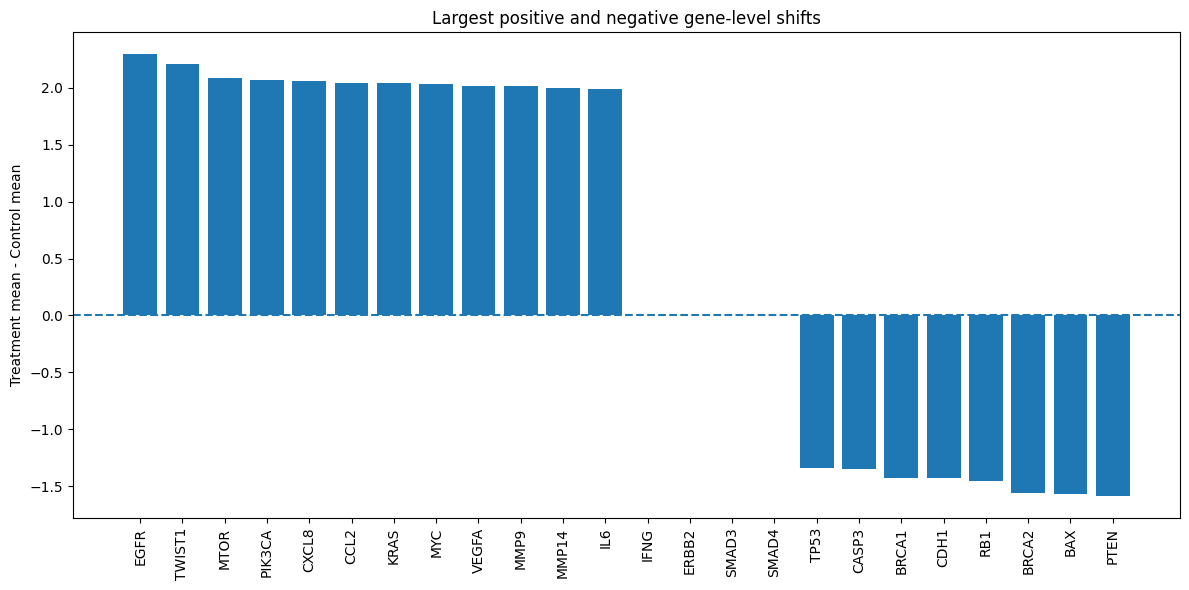

In [11]:
top_changed = pd.concat([
    gene_level_summary.head(12),
    gene_level_summary.tail(12)
])

plt.figure(figsize=(12, 6))
plt.bar(top_changed["gene_id"], top_changed["treatment_minus_control"])
plt.axhline(0, linestyle="--")
plt.xticks(rotation=90)
plt.ylabel("Treatment mean - Control mean")
plt.title("Largest positive and negative gene-level shifts")
plt.tight_layout()
plt.show()

## Plot reflection

This plot helps me check that the toy dataset is doing what I meant it to do.

The genes with higher treatment values are mostly the ones I expected to move up, like signaling, inflammation, invasion, and EMT related genes. The genes with lower treatment values are mostly genes connected to tumor suppression, DNA repair, apoptosis, and cell adhesion.

I wanted this step before pathway analysis because I do not want to just trust a pathway name without looking at the genes underneath it. If a pathway looks important later, I want to be able to trace it back to the actual genes that caused that signal.

# Custom pathway groups

Now I am creating small pathway groups from the genes in the toy dataset.

I am starting with custom groups instead of jumping straight into a large database because I want to understand the structure first. Since I know which genes are inside each group, I can check whether the pathway level results match the signal I built into the data.

This also helps me understand what pyGAGE expects before moving to larger pathway databases like KEGG or GO.

In [12]:
gene_sets = {
    "growth_factor_MAPK_PI3K_signaling": [
        "EGFR", "KRAS", "NRAS", "BRAF", "MAPK1", "MAPK3", "PIK3CA", "AKT1", "MTOR"
    ],
    "inflammation_STAT3_NFkB_axis": [
        "IL6", "STAT3", "JAK2", "TNF", "NFKB1", "RELA", "CXCL8", "CCL2", "CXCL10", "IFNG", "IRF1"
    ],
    "cell_cycle_proliferation": [
        "MYC", "CDK1", "CDK2", "CCND1", "MKI67", "RB1"
    ],
    "DNA_repair_genome_stability": [
        "BRCA1", "BRCA2", "RAD51", "TP53"
    ],
    "apoptosis_balance": [
        "CASP3", "BCL2", "BAX", "TP53"
    ],
    "hypoxia_angiogenesis_invasion": [
        "HIF1A", "VEGFA", "MMP2", "MMP9", "MMP14"
    ],
    "EMT_cell_migration": [
        "CDH1", "VIM", "SNAI1", "TWIST1", "MMP2", "MMP9"
    ],
    "TGF_beta_signaling": [
        "TGFB1", "SMAD2", "SMAD3", "SMAD4"
    ]
}

gene_set_summary = pd.DataFrame({
    "gene_set": list(gene_sets.keys()),
    "n_genes": [len(genes_in_set) for genes_in_set in gene_sets.values()],
    "genes": [", ".join(genes_in_set) for genes_in_set in gene_sets.values()]
})

display(gene_set_summary)

,gene_set,n_genes,genes
0,growth_factor_MAPK_PI3K_signaling,9,"EGFR, KRAS, NRAS, BRAF, MAPK1, MAPK3, PIK3CA, ..."
1,inflammation_STAT3_NFkB_axis,11,"IL6, STAT3, JAK2, TNF, NFKB1, RELA, CXCL8, CCL..."
2,cell_cycle_proliferation,6,"MYC, CDK1, CDK2, CCND1, MKI67, RB1"
3,DNA_repair_genome_stability,4,"BRCA1, BRCA2, RAD51, TP53"
4,apoptosis_balance,4,"CASP3, BCL2, BAX, TP53"
5,hypoxia_angiogenesis_invasion,5,"HIF1A, VEGFA, MMP2, MMP9, MMP14"
6,EMT_cell_migration,6,"CDH1, VIM, SNAI1, TWIST1, MMP2, MMP9"
7,TGF_beta_signaling,4,"TGFB1, SMAD2, SMAD3, SMAD4"


## Gene group note

This table shows the pathway groups I am using for the controlled test.

I like seeing the groups in a table before running the analysis because it makes the input easier to check. If a pathway result appears later, I can look back here and see exactly which genes were included.

This is also a reminder that pathway analysis depends heavily on the gene sets being used. The same expression data can tell a different story depending on how the genes are grouped.

# Manual pathway level check

Before running pyGAGE, I want to do a simple manual pathway level check.

This is not replacing the real GAGE analysis. I am using it as an intuition check. If most genes in a group move upward, I would expect that group to have a positive pathway level signal. If the genes are mixed, I should be more careful with interpretation.

This step helps me understand the data before asking the package to do the formal analysis.

In [13]:
effect_map = dict(zip(gene_level_summary["gene_id"], gene_level_summary["treatment_minus_control"]))

manual_pathway_results = []

for pathway_name, pathway_genes in gene_sets.items():
    found_genes = [gene for gene in pathway_genes if gene in effect_map]
    effects = [effect_map[gene] for gene in found_genes]

    positive_genes = [gene for gene in found_genes if effect_map[gene] > 0]
    negative_genes = [gene for gene in found_genes if effect_map[gene] < 0]
    unchanged_genes = [gene for gene in found_genes if effect_map[gene] == 0]

    manual_pathway_results.append({
        "gene_set": pathway_name,
        "genes_found": len(found_genes),
        "mean_effect": np.mean(effects),
        "positive_genes": ", ".join(positive_genes),
        "negative_genes": ", ".join(negative_genes),
        "unchanged_genes": ", ".join(unchanged_genes)
    })

manual_pathway_summary = pd.DataFrame(manual_pathway_results)
manual_pathway_summary = manual_pathway_summary.sort_values("mean_effect", ascending=False)

display(manual_pathway_summary)

,gene_set,genes_found,mean_effect,positive_genes,negative_genes,unchanged_genes
5,hypoxia_angiogenesis_invasion,5,1.581350,"VEGFA, MMP2, MMP9, MMP14",,HIF1A
6,EMT_cell_migration,6,1.429642,"VIM, SNAI1, TWIST1, MMP2, MMP9",CDH1,
0,growth_factor_MAPK_PI3K_signaling,9,1.140380,"EGFR, KRAS, PIK3CA, AKT1, MTOR",,"NRAS, BRAF, MAPK1, MAPK3"
1,inflammation_STAT3_NFkB_axis,11,0.903709,"IL6, STAT3, RELA, CXCL8, CCL2",,"JAK2, TNF, NFKB1, CXCL10, IFNG, IRF1"
2,cell_cycle_proliferation,6,0.421238,"MYC, MKI67",RB1,"CDK1, CDK2, CCND1"
7,TGF_beta_signaling,4,0.000000,,,"TGFB1, SMAD2, SMAD3, SMAD4"
4,apoptosis_balance,4,-1.063309,,"CASP3, BAX, TP53",BCL2
3,DNA_repair_genome_stability,4,-1.079007,,"BRCA1, BRCA2, TP53",RAD51


## Manual pathway check note

This table gives me a simple pathway level expectation before running the formal GAGE analysis.

For example, if a group has a high positive mean effect and most of its genes are listed under positive genes, I would expect that group to show an upward signal. If a group has both positive and negative genes, then the interpretation should be more careful.

I like this step because it keeps the pathway analysis connected to the gene level data instead of making the output feel like a black box.

# Running pyGAGE on the controlled dataset

Now I am going to run the actual pyGAGE workflow using the controlled expression matrix and the custom gene sets.

At this point, I have already checked three things:

1. the package imports
2. the core workflow classes are available through `pygage.core`
3. the gene level and manual pathway level signal make sense

Now I want to see whether the formal GAGE output matches the expected pattern.

In [14]:
from pygage.core import GAGEPreparation, GAGEAnalysis

prep = GAGEPreparation()

prepared_expr = prep.prepare_expression(
    expr,
    ref_indices=[1, 2, 3],
    samp_indices=[4, 5, 6],
    comparison="paired"
)

gage = GAGEAnalysis()

gage_results = gage.run_gage(
    prepared_expr,
    gene_sets,
    gene_col="gene_id",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print(type(gage_results))
print(gage_results)

ColumnNotFoundError: unable to find column "gene_id"; valid columns: ["diff_treatment_1", "diff_treatment_2", "diff_treatment_3"]

## First pyGAGE run check

The first pyGAGE run stopped because the prepared expression table did not include the `gene_id` column.

This is actually useful to see because it shows what `prepare_expression()` returns before passing the data into `run_gage()`. The prepared table contains the treatment difference columns, but I still need the gene identifiers attached so the gene sets can match back to the expression rows.

My next step is to inspect the prepared table, add the gene identifiers back in, and rerun the GAGE step with the corrected input.

In [15]:
print("Prepared expression table:")
print(prepared_expr)

print("\nColumns:")
print(prepared_expr.columns)

Prepared expression table:
shape: (50, 3)
┌──────────────────┬──────────────────┬──────────────────┐
│ diff_treatment_1 ┆ diff_treatment_2 ┆ diff_treatment_3 │
│ ---              ┆ ---              ┆ ---              │
│ f64              ┆ f64              ┆ f64              │
╞══════════════════╪══════════════════╪══════════════════╡
│ -0.192383        ┆ -0.129313        ┆ -0.208962        │
│ 0.244863         ┆ 0.2478           ┆ 0.26135          │
│ 0.183219         ┆ 0.240984         ┆ 0.249085         │
│ 0.243516         ┆ 0.197656         ┆ 0.247316         │
│ 0.0              ┆ 0.0              ┆ 0.0              │
│ …                ┆ …                ┆ …                │
│ 0.240734         ┆ 0.240593         ┆ 0.208715         │
│ 0.218615         ┆ 0.221494         ┆ 0.222353         │
│ 0.0              ┆ 0.0              ┆ 0.0              │
│ 0.0              ┆ 0.0              ┆ 0.0              │
│ 0.0              ┆ 0.0              ┆ 0.0              │
└─────────────

In [16]:
prepared_with_genes = prepared_expr.with_columns(
    pl.Series("gene_id", expr_pd["gene_id"].tolist())
)

print("Prepared expression table with gene IDs added back:")
print(prepared_with_genes)

print("\nColumns:")
print(prepared_with_genes.columns)

Prepared expression table with gene IDs added back:
shape: (50, 4)
┌──────────────────┬──────────────────┬──────────────────┬─────────┐
│ diff_treatment_1 ┆ diff_treatment_2 ┆ diff_treatment_3 ┆ gene_id │
│ ---              ┆ ---              ┆ ---              ┆ ---     │
│ f64              ┆ f64              ┆ f64              ┆ str     │
╞══════════════════╪══════════════════╪══════════════════╪═════════╡
│ -0.192383        ┆ -0.129313        ┆ -0.208962        ┆ TP53    │
│ 0.244863         ┆ 0.2478           ┆ 0.26135          ┆ EGFR    │
│ 0.183219         ┆ 0.240984         ┆ 0.249085         ┆ MYC     │
│ 0.243516         ┆ 0.197656         ┆ 0.247316         ┆ KRAS    │
│ 0.0              ┆ 0.0              ┆ 0.0              ┆ NRAS    │
│ …                ┆ …                ┆ …                ┆ …       │
│ 0.240734         ┆ 0.240593         ┆ 0.208715         ┆ MMP14   │
│ 0.218615         ┆ 0.221494         ┆ 0.222353         ┆ CCL2    │
│ 0.0              ┆ 0.0            

In [17]:
gage_results = gage.run_gage(
    prepared_with_genes,
    gene_sets,
    gene_col="gene_id",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print(type(gage_results))
print(gage_results)

<class 'dict'>
{'greater': shape: (8, 6)
┌─────────────────────────────────┬──────────┬───────────┬───────────┬──────────┬───────────┐
│ gene_set                        ┆ set_size ┆ stat_mean ┆ p_greater ┆ p_less   ┆ q_greater │
│ ---                             ┆ ---      ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str                             ┆ i64      ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═════════════════════════════════╪══════════╪═══════════╪═══════════╪══════════╪═══════════╡
│ hypoxia_angiogenesis_invasion   ┆ 5        ┆ 0.18023   ┆ 0.023613  ┆ 0.976387 ┆ 0.1889    │
│ growth_factor_MAPK_PI3K_signal… ┆ 9        ┆ 0.125786  ┆ 0.052475  ┆ 0.947525 ┆ 0.204236  │
│ inflammation_STAT3_NFkB_axis    ┆ 11       ┆ 0.099694  ┆ 0.101267  ┆ 0.898733 ┆ 0.204236  │
│ EMT_cell_migration              ┆ 6        ┆ 0.155377  ┆ 0.102118  ┆ 0.897882 ┆ 0.204236  │
│ cell_cycle_proliferation        ┆ 6        ┆ 0.038815  ┆ 0.578868  ┆ 0.421132 ┆ 0.926189  │
│ apoptosis_balance

## Corrected pyGAGE run

After inspecting the prepared expression table, I added the gene identifiers back before running `run_gage()` again. This worked because the pathway gene sets need a gene ID column to match each expression row to the correct gene group.

This step was useful because it showed me how the workflow changes the data between preparation and analysis. Instead of treating the error like a dead end, I used it to understand what the package expected next.

In [19]:
#RUN 2
from pygage.core import GAGEPreparation, GAGEAnalysis

prep = GAGEPreparation()

prepared_expr = prep.prepare_expression(
    expr,
    ref_indices=[1, 2, 3],
    samp_indices=[4, 5, 6],
    comparison="paired"
)

gage = GAGEAnalysis()

gage_results = gage.run_gage(
    prepared_with_genes,
    gene_sets,
    gene_col="gene_id",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print(type(gage_results))
print(gage_results)

<class 'dict'>
{'greater': shape: (8, 6)
┌─────────────────────────────────┬──────────┬───────────┬───────────┬──────────┬───────────┐
│ gene_set                        ┆ set_size ┆ stat_mean ┆ p_greater ┆ p_less   ┆ q_greater │
│ ---                             ┆ ---      ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str                             ┆ i64      ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═════════════════════════════════╪══════════╪═══════════╪═══════════╪══════════╪═══════════╡
│ hypoxia_angiogenesis_invasion   ┆ 5        ┆ 0.18023   ┆ 0.023613  ┆ 0.976387 ┆ 0.1889    │
│ growth_factor_MAPK_PI3K_signal… ┆ 9        ┆ 0.125786  ┆ 0.052475  ┆ 0.947525 ┆ 0.204236  │
│ inflammation_STAT3_NFkB_axis    ┆ 11       ┆ 0.099694  ┆ 0.101267  ┆ 0.898733 ┆ 0.204236  │
│ EMT_cell_migration              ┆ 6        ┆ 0.155377  ┆ 0.102118  ┆ 0.897882 ┆ 0.204236  │
│ cell_cycle_proliferation        ┆ 6        ┆ 0.038815  ┆ 0.578868  ┆ 0.421132 ┆ 0.926189  │
│ apoptosis_balance

## Corrected pyGAGE run

After adding the `gene_id` column back to the prepared expression table, pyGAGE ran successfully on the controlled dataset.

The output gives three result sections:

1. `greater`, which tests gene sets with a positive direction
2. `less`, which tests gene sets with a negative direction
3. `stats`, which summarizes the mean statistic and set size for each gene group

This is useful because the formal pyGAGE output mostly matches the manual pathway check I did earlier. The strongest positive signals include hypoxia, angiogenesis, invasion, growth signaling, inflammation, and EMT related groups. The negative side includes DNA repair/genome stability and apoptosis balance.

The important thing I learned here is that the workflow is not just about getting the package to run. I also need to understand how the prepared expression table changes, how gene IDs are matched back to gene sets, and how the output direction connects to the biology.

In [21]:
#easier to read
greater_results = gage_results["greater"].to_pandas()
less_results = gage_results["less"].to_pandas()
stats_results = gage_results["stats"].to_pandas()

print("Positive direction results")
display(greater_results)

print("Negative direction results")
display(less_results)

print("Summary stats")
display(stats_results)

Positive direction results


,gene_set,set_size,stat_mean,p_greater,p_less,q_greater
0,hypoxia_angiogenesis_invasion,5,0.180230,0.023613,0.976387,0.188900
1,growth_factor_MAPK_PI3K_signaling,9,0.125786,0.052475,0.947525,0.204236
2,inflammation_STAT3_NFkB_axis,11,0.099694,0.101267,0.898733,0.204236
3,EMT_cell_migration,6,0.155377,0.102118,0.897882,0.204236
4,cell_cycle_proliferation,6,0.038815,0.578868,0.421132,0.926189
5,apoptosis_balance,4,-0.149602,0.985589,0.014411,1.000000
6,DNA_repair_genome_stability,4,-0.143989,0.986591,0.013409,1.000000
7,TGF_beta_signaling,4,0.000000,1.000000,0.000000,1.000000


Negative direction results


,gene_set,set_size,stat_mean,p_greater,p_less,q_less
0,TGF_beta_signaling,4,0.000000,1.000000,0.000000,0.000000
1,DNA_repair_genome_stability,4,-0.143989,0.986591,0.013409,0.038431
2,apoptosis_balance,4,-0.149602,0.985589,0.014411,0.038431
3,cell_cycle_proliferation,6,0.038815,0.578868,0.421132,0.842263
4,EMT_cell_migration,6,0.155377,0.102118,0.897882,0.976387
5,inflammation_STAT3_NFkB_axis,11,0.099694,0.101267,0.898733,0.976387
6,growth_factor_MAPK_PI3K_signaling,9,0.125786,0.052475,0.947525,0.976387
7,hypoxia_angiogenesis_invasion,5,0.180230,0.023613,0.976387,0.976387


Summary stats


,gene_set,stat_mean,set_size
0,growth_factor_MAPK_PI3K_signaling,0.125786,9
1,inflammation_STAT3_NFkB_axis,0.099694,11
2,cell_cycle_proliferation,0.038815,6
3,DNA_repair_genome_stability,-0.143989,4
4,apoptosis_balance,-0.149602,4
5,hypoxia_angiogenesis_invasion,0.180230,5
6,EMT_cell_migration,0.155377,6
7,TGF_beta_signaling,0.000000,4


## Making the output easier to read

The raw pyGAGE output works, but converting each result section into a table makes the results much easier to inspect.

This is especially helpful for someone who is still learning pathway analysis because they can compare the positive direction table, the negative direction table, and the summary statistics side by side.

In [22]:
greater_results = gage_results["greater"].to_pandas()
less_results = gage_results["less"].to_pandas()
stats_results = gage_results["stats"].to_pandas()

combined_results = stats_results.merge(
    greater_results[["gene_set", "p_greater", "q_greater"]],
    on="gene_set",
    how="left"
).merge(
    less_results[["gene_set", "p_less", "q_less"]],
    on="gene_set",
    how="left"
)

combined_results = combined_results.sort_values("stat_mean", ascending=False)

display(combined_results)

,gene_set,stat_mean,set_size,p_greater,q_greater,p_less,q_less
5,hypoxia_angiogenesis_invasion,0.180230,5,0.023613,0.188900,0.976387,0.976387
6,EMT_cell_migration,0.155377,6,0.102118,0.204236,0.897882,0.976387
0,growth_factor_MAPK_PI3K_signaling,0.125786,9,0.052475,0.204236,0.947525,0.976387
1,inflammation_STAT3_NFkB_axis,0.099694,11,0.101267,0.204236,0.898733,0.976387
2,cell_cycle_proliferation,0.038815,6,0.578868,0.926189,0.421132,0.842263
7,TGF_beta_signaling,0.000000,4,1.000000,1.000000,0.000000,0.000000
3,DNA_repair_genome_stability,-0.143989,4,0.986591,1.000000,0.013409,0.038431
4,apoptosis_balance,-0.149602,4,0.985589,1.000000,0.014411,0.038431


## Combined results table

I combined the pyGAGE output into one table so I can compare each gene group in one place.

This makes the result easier to read because I can look at the mean direction of the gene group, the positive direction values, and the negative direction values together instead of jumping between separate outputs.

This also makes it easier to compare the formal pyGAGE result back to my manual pathway check.

In [23]:
interpretation_table = pd.DataFrame({
    "gene_set": [
        "hypoxia_angiogenesis_invasion",
        "growth_factor_MAPK_PI3K_signaling",
        "inflammation_STAT3_NFkB_axis",
        "EMT_cell_migration",
        "cell_cycle_proliferation",
        "DNA_repair_genome_stability",
        "apoptosis_balance",
        "TGF_beta_signaling"
    ],
    "expected_direction_from_toy_data": [
        "positive",
        "positive",
        "positive",
        "positive",
        "mild positive or mixed",
        "negative",
        "negative",
        "mostly unchanged"
    ],
    "how_I_am_reading_the_result": [
        "This fits the simulated increase in VEGFA, MMP2, MMP9, and MMP14, so the positive direction makes sense for this toy signal.",
        "This fits the simulated increase in EGFR, KRAS, PIK3CA, AKT1, and MTOR, which were meant to create a signaling related shift.",
        "This fits the simulated increase in IL6, STAT3, RELA, CXCL8, and CCL2, so the inflammatory group moving positive makes sense.",
        "This fits the simulated increase in VIM, SNAI1, TWIST1, MMP2, and MMP9, while CDH1 moves in the opposite direction.",
        "This is weaker because only some genes in the group move strongly, so I would be careful not to overstate it.",
        "This fits the simulated decrease in BRCA1, BRCA2, and TP53.",
        "This fits the simulated decrease in CASP3, BAX, and TP53, although apoptosis is not something I would simplify too much.",
        "This looks mostly unchanged in the toy data, which is useful because not every group should look strongly shifted."
    ],
    "what_I_would_be_careful_about": [
        "I would not claim real angiogenesis from toy data. I would only say the test signal behaves as expected.",
        "I would still check the individual genes before saying the whole pathway is activated.",
        "In a real dataset, I would connect this back to the sample type and condition before making a biological claim.",
        "EMT is complex, so I would not treat one small marker group as a full EMT conclusion.",
        "I would call this a weak or mixed signal.",
        "I would not say DNA repair is biologically impaired without real experimental context.",
        "I would not reduce apoptosis to one direction without looking at each gene role.",
        "I would use this as a check that the method is not making every group look important."
    ]
})

display(interpretation_table)

,gene_set,expected_direction_from_toy_data,how_I_am_reading_the_result,what_I_would_be_careful_about
0,hypoxia_angiogenesis_invasion,positive,"This fits the simulated increase in VEGFA, MMP...",I would not claim real angiogenesis from toy d...
1,growth_factor_MAPK_PI3K_signaling,positive,"This fits the simulated increase in EGFR, KRAS...",I would still check the individual genes befor...
2,inflammation_STAT3_NFkB_axis,positive,"This fits the simulated increase in IL6, STAT3...","In a real dataset, I would connect this back t..."
3,EMT_cell_migration,positive,"This fits the simulated increase in VIM, SNAI1...","EMT is complex, so I would not treat one small..."
4,cell_cycle_proliferation,mild positive or mixed,This is weaker because only some genes in the ...,I would call this a weak or mixed signal.
5,DNA_repair_genome_stability,negative,"This fits the simulated decrease in BRCA1, BRC...",I would not say DNA repair is biologically imp...
6,apoptosis_balance,negative,"This fits the simulated decrease in CASP3, BAX...",I would not reduce apoptosis to one direction ...
7,TGF_beta_signaling,mostly unchanged,"This looks mostly unchanged in the toy data, w...",I would use this as a check that the method is...


## Biological interpretation table

I added this table because I do not want the pathway analysis to stop at p values.

For me, the useful part is connecting the output back to the genes driving the signal and asking what I can responsibly say from the result. This is especially important in bioinformatics because it is easy to overstate a pathway name if I do not check the underlying genes.

This table helps me separate three things:

1. what direction I expected from the toy dataset
2. how the pyGAGE result compares to that expectation
3. what I would be careful not to overclaim

That makes the analysis feel more connected to biology instead of just being a table of numbers.